In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================
# 1. Imports
# =========================

import os
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# =========================
# 2. Paths
# =========================

ROOT_DIR = "/content/drive/MyDrive/Senior_Project/03_Results"

TFIDF_RESULTS_PATH = f"{ROOT_DIR}/Baselines/Short_Form/tfidf_baseline_results.csv"
SENT_RESULTS_PATH = f"{ROOT_DIR}/Sentiment/sentiment_rhetoric_results.csv"
BERT_RESULTS_PATH = f"{ROOT_DIR}/BERT/Final_Short_Form_Probs/results/bert_results.csv"
FUSION_RESULTS_PATH = f"{ROOT_DIR}/Fusion/fusion_results.csv"

OUT_DIR = f"{ROOT_DIR}/Visuals"
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
# =========================
# Dataset Sample Sizes + Fake/Real Distribution
# =========================

import pandas as pd

BASE_DATA_DIR = "/content/drive/MyDrive/Senior_Project/00_Data/cleaned/Final_Short_Form"

FEATURE_PATHS = {
    "liar": {
        "path": f"{BASE_DATA_DIR}/LIAR/liar_vader_rhetorical.csv",
    },
    "covid": {
        "path": f"{BASE_DATA_DIR}/COVID/covid_vader_rhetorical.csv",
    },
    "sensational": {
        "path": f"{BASE_DATA_DIR}/Sensational/sensational_features_full.csv",
    },
    "baseline": {
        "path": f"{BASE_DATA_DIR}/LIAR+COVID/liar_covid_features_full.csv",
    },
    "combined": {
        "path": f"{BASE_DATA_DIR}/Combined/combined_full.csv",
    }
}

summary_rows = []

for dataset_name, info in FEATURE_PATHS.items():

    df = pd.read_csv(info["path"])

    total_samples = len(df)

    fake_count = (df["is_fake"] == 1).sum()
    real_count = (df["is_fake"] == 0).sum()

    fake_pct = (fake_count / total_samples) * 100
    real_pct = (real_count / total_samples) * 100

    summary_rows.append({
        "dataset": dataset_name,
        "samples": total_samples,
        "fake_count": fake_count,
        "real_count": real_count,
        "fake_pct": round(fake_pct, 1),
        "real_pct": round(real_pct, 1)
    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

,dataset,samples,fake_count,real_count,fake_pct,real_pct
0,liar,10796,4647,6149,43.0,57.0
1,covid,9599,4187,5412,43.6,56.4
2,sensational,1208,604,604,50.0,50.0
3,baseline,20395,8834,11561,43.3,56.7
4,combined,21603,9438,12165,43.7,56.3


In [ ]:
# =========================
# 3. Load results
# =========================

tfidf_df = pd.read_csv(TFIDF_RESULTS_PATH)
sent_df = pd.read_csv(SENT_RESULTS_PATH)
bert_df = pd.read_csv(BERT_RESULTS_PATH)
fusion_df = pd.read_csv(FUSION_RESULTS_PATH)

print("TF-IDF columns:", tfidf_df.columns.tolist())
print("Sent/Rhet columns:", sent_df.columns.tolist())
print("BERT columns:", bert_df.columns.tolist())
print("Fusion columns:", fusion_df.columns.tolist())

TF-IDF columns: ['train_dataset', 'test_dataset', 'model', 'accuracy', 'precision', 'recall', 'f1', 'tn', 'fp', 'fn', 'tp']
Sent/Rhet columns: ['train_dataset', 'test_dataset', 'model', 'accuracy', 'precision', 'recall', 'f1', 'tn', 'fp', 'fn', 'tp']
BERT columns: ['bert_model', 'test_dataset', 'test_rows', 'prediction_rows', 'merged_rows', 'id_col_test', 'id_col_pred', 'threshold', 'accuracy', 'precision', 'recall', 'f1', 'tn', 'fp', 'fn', 'tp']
Fusion columns: ['experiment', 'bert_model', 'train_dataset', 'test_dataset', 'fusion_model', 'train_rows', 'test_rows', 'accuracy', 'precision', 'recall', 'f1', 'tn', 'fp', 'fn', 'tp']


In [ ]:
# =========================
# 4. Extract Combined → Combined scores
# =========================

comparison_rows = []

# TF-IDF: train_dataset = combined, test_dataset = combined
tfidf_combined = tfidf_df[
    (tfidf_df["train_dataset"] == "combined") &
    (tfidf_df["test_dataset"] == "combined")
].copy()

best_tfidf = tfidf_combined.sort_values("f1", ascending=False).iloc[0]

comparison_rows.append({
    "pipeline": "TF-IDF",
    "model": best_tfidf["model"],
    "train_dataset": "combined",
    "test_dataset": "combined",
    "f1": best_tfidf["f1"]
})


# Sentiment/Rhetoric: train_dataset = combined, test_dataset = combined
sent_combined = sent_df[
    (sent_df["train_dataset"] == "combined") &
    (sent_df["test_dataset"] == "combined")
].copy()

best_sent = sent_combined.sort_values("f1", ascending=False).iloc[0]

comparison_rows.append({
    "pipeline": "Sentiment/Rhetoric",
    "model": best_sent["model"],
    "train_dataset": "combined",
    "test_dataset": "combined",
    "f1": best_sent["f1"]
})


# BERT: bert_model = combined_model, test_dataset = combined
bert_combined = bert_df[
    (bert_df["bert_model"] == "combined_model") &
    (bert_df["test_dataset"] == "combined")
].copy()

best_bert = bert_combined.sort_values("f1", ascending=False).iloc[0]

comparison_rows.append({
    "pipeline": "BERT",
    "model": best_bert["bert_model"],
    "train_dataset": "combined",
    "test_dataset": "combined",
    "f1": best_bert["f1"]
})


# Fusion: experiment = combined_fusion, test_dataset = combined
fusion_combined = fusion_df[
    (fusion_df["experiment"] == "combined_fusion") &
    (fusion_df["test_dataset"] == "combined")
].copy()

best_fusion = fusion_combined.sort_values("f1", ascending=False).iloc[0]

comparison_rows.append({
    "pipeline": "Fusion",
    "model": best_fusion["fusion_model"],
    "train_dataset": "combined",
    "test_dataset": "combined",
    "f1": best_fusion["f1"]
})


comparison_df = pd.DataFrame(comparison_rows)
comparison_df.head(20)

,pipeline,model,train_dataset,test_dataset,f1
0,TF-IDF,TF-IDF + LinearSVC,combined,combined,0.698172
1,Sentiment/Rhetoric,SentRhet_LogReg,combined,combined,0.597043
2,BERT,combined_model,combined,combined,0.705812
3,Fusion,Fusion_LogReg,combined,combined,0.760824


In [ ]:
# =========================
# 5. Save comparison table
# =========================

comparison_path = f"{OUT_DIR}/all_pipeline_comparisons.csv"
comparison_df.to_csv(comparison_path, index=False)

print("Saved:", comparison_path)
comparison_df

Saved: /content/drive/MyDrive/Senior_Project/03_Results/Visuals/all_pipeline_comparisons.csv


,pipeline,model,train_dataset,test_dataset,f1
0,TF-IDF,TF-IDF + LinearSVC,combined,combined,0.698172
1,Sentiment/Rhetoric,SentRhet_LogReg,combined,combined,0.597043
2,BERT,combined_model,combined,combined,0.705812
3,Fusion,Fusion_LogReg,combined,combined,0.760824


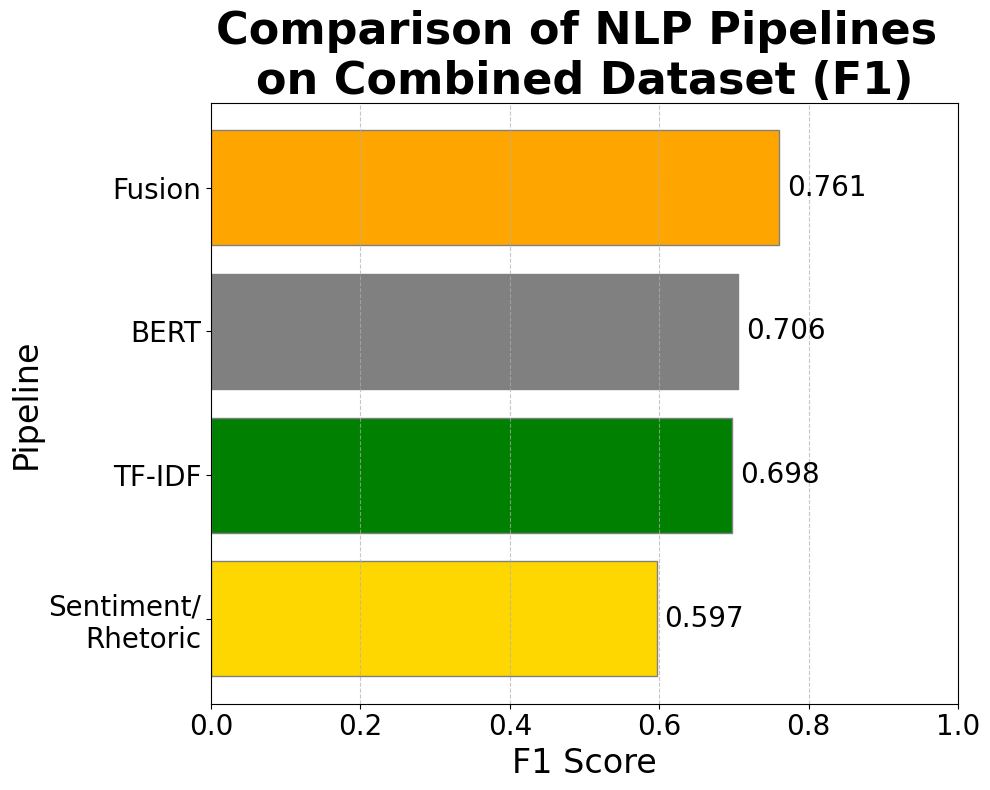

Saved enhanced graph: /content/drive/MyDrive/Senior_Project/03_Results/Visuals/combined_pipeline_comparison_f1_enhanced.png


In [ ]:
# =========================
# 6. Graph 1.1: Combined → Combined pipeline comparison
# =========================

plot_df = comparison_df.sort_values("f1", ascending=True)

# Replace '/' with '\n' in the pipeline names for better readability
plot_df["pipeline"] = plot_df["pipeline"].str.replace("/", "/\n")

plt.figure(figsize=(10, 8))

# Define a distinct color palette for each bar
colors = ['gold', 'green', 'grey', 'orange'] # Hand-picked distinct colors

bars = plt.barh(plot_df["pipeline"], plot_df["f1"], color=colors, edgecolor='grey')

plt.title("Comparison of NLP Pipelines \non Combined Dataset (F1)", fontsize=32, fontweight='bold')
plt.xlabel("F1 Score", fontsize=24)
plt.ylabel("Pipeline", fontsize=24)
plt.xlim(0, 1)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Add grid for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}", # Display 3 decimal places for F1 score
        va="center",
        fontsize=20
    )

plt.tight_layout()

out_graph = f"{OUT_DIR}/combined_pipeline_comparison_f1_enhanced.png"
plt.savefig(out_graph, dpi=300, bbox_inches="tight")
plt.show()

print("Saved enhanced graph:", out_graph)


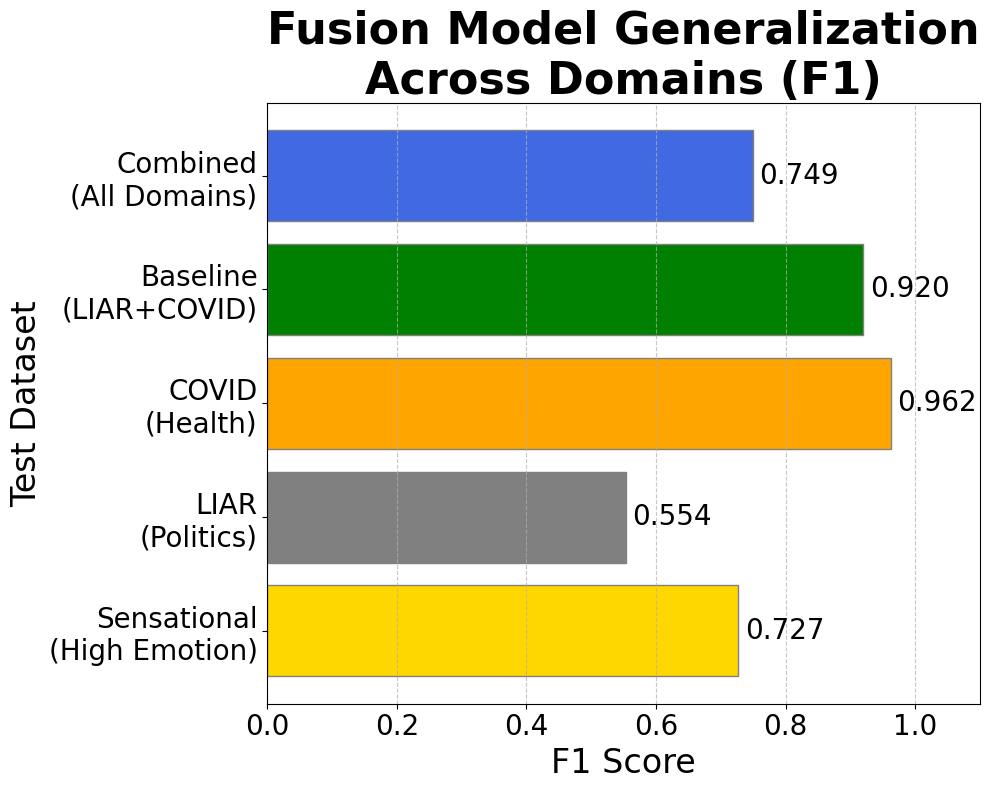

Saved graph: /content/drive/MyDrive/Senior_Project/03_Results/Visuals/fusion_generalization_across_domains_f1.png


In [ ]:
# =========================
# 7. Graph 2: Fusion Model Generalization Across Domains
# =========================

# Use combined fusion + Random Forest as final fusion model
graph2_df = fusion_df[
    (fusion_df["experiment"] == "combined_fusion") &
    (fusion_df["fusion_model"] == "Fusion_RF")
].copy()

# Optional order for readability
domain_order = ["sensational", "liar", "covid", "baseline", "combined"]

graph2_df["test_dataset"] = pd.Categorical(
    graph2_df["test_dataset"],
    categories=domain_order,
    ordered=True
)

graph2_df = graph2_df.sort_values("test_dataset")

# Rename labels for poster
label_map = {
    "liar": "LIAR\n(Politics)",
    "covid": "COVID\n(Health)",
    "baseline": "Baseline\n(LIAR+COVID)",
    "sensational": "Sensational\n(High Emotion)",
    "combined": "Combined\n(All Domains)"
}

graph2_df["domain_label"] = graph2_df["test_dataset"].map(label_map)

plt.figure(figsize=(10, 8))

colors = ['gold', 'grey', 'orange', 'green', 'royalblue']

bars = plt.barh(
    graph2_df["domain_label"],
    graph2_df["f1"],
    color=colors,
    edgecolor="grey"
)

plt.title("Fusion Model Generalization\nAcross Domains (F1)", fontsize=32, fontweight="bold")
plt.xlabel("F1 Score", fontsize=24)
plt.ylabel("Test Dataset", fontsize=24)
plt.xlim(0, 1.1) # Increased xlim to provide space for text labels
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.grid(axis="x", linestyle="--", alpha=0.7)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=20
    )

plt.tight_layout()

out_graph = f"{OUT_DIR}/fusion_generalization_across_domains_f1.png"
plt.savefig(out_graph, dpi=300, bbox_inches="tight")
plt.show()

print("Saved graph:", out_graph)


In [ ]:
# =========================
# 8. Graph 3: Pipeline Performance Across Domains
# =========================

graph3_rows = []

domains = ["liar", "covid", "sensational", "baseline", "combined"]

# TF-IDF: combined-trained best TF-IDF model across each domain
for domain in domains:
    temp = tfidf_df[
        (tfidf_df["train_dataset"] == "combined") &
        (tfidf_df["test_dataset"] == domain)
    ].copy()

    best = temp.sort_values("f1", ascending=False).iloc[0]

    graph3_rows.append({
        "domain": domain,
        "pipeline": "TF-IDF",
        "f1": best["f1"]
    })


# BERT: combined_model across each domain
for domain in domains:
    temp = bert_df[
        (bert_df["bert_model"] == "combined_model") &
        (bert_df["test_dataset"] == domain)
    ].copy()

    best = temp.sort_values("f1", ascending=False).iloc[0]

    graph3_rows.append({
        "domain": domain,
        "pipeline": "BERT",
        "f1": best["f1"]
    })


# Fusion: combined_fusion + best fusion classifier across each domain
for domain in domains:
    temp = fusion_df[
        (fusion_df["experiment"] == "combined_fusion") &
        (fusion_df["test_dataset"] == domain)
    ].copy()

    best = temp.sort_values("f1", ascending=False).iloc[0]

    graph3_rows.append({
        "domain": domain,
        "pipeline": "Fusion",
        "f1": best["f1"]
    })


graph3_df = pd.DataFrame(graph3_rows)

# Rename domains for poster
domain_label_map = {
    "liar": "LIAR\n(Politics)",
    "covid": "COVID\n(Health)",
    "sensational": "Sensational\n(High Emotion)",
    "baseline": "Baseline\n(LIAR+COVID)", # Added baseline
    "combined": "Combined\n(All Domains)"
}

graph3_df["domain_label"] = graph3_df["domain"].map(domain_label_map)

graph3_df

,domain,pipeline,f1,domain_label
0,liar,TF-IDF,0.504535,LIAR\n(Politics)
1,covid,TF-IDF,0.914804,COVID\n(Health)
2,sensational,TF-IDF,0.658537,Sensational\n(High Emotion)
3,baseline,TF-IDF,0.826381,Baseline\n(LIAR+COVID)
4,combined,TF-IDF,0.698172,Combined\n(All Domains)
5,liar,BERT,0.434066,LIAR\n(Politics)
6,covid,BERT,0.949878,COVID\n(Health)
7,sensational,BERT,0.691057,Sensational\n(High Emotion)
8,baseline,BERT,0.757788,Baseline\n(LIAR+COVID)
9,combined,BERT,0.705812,Combined\n(All Domains)


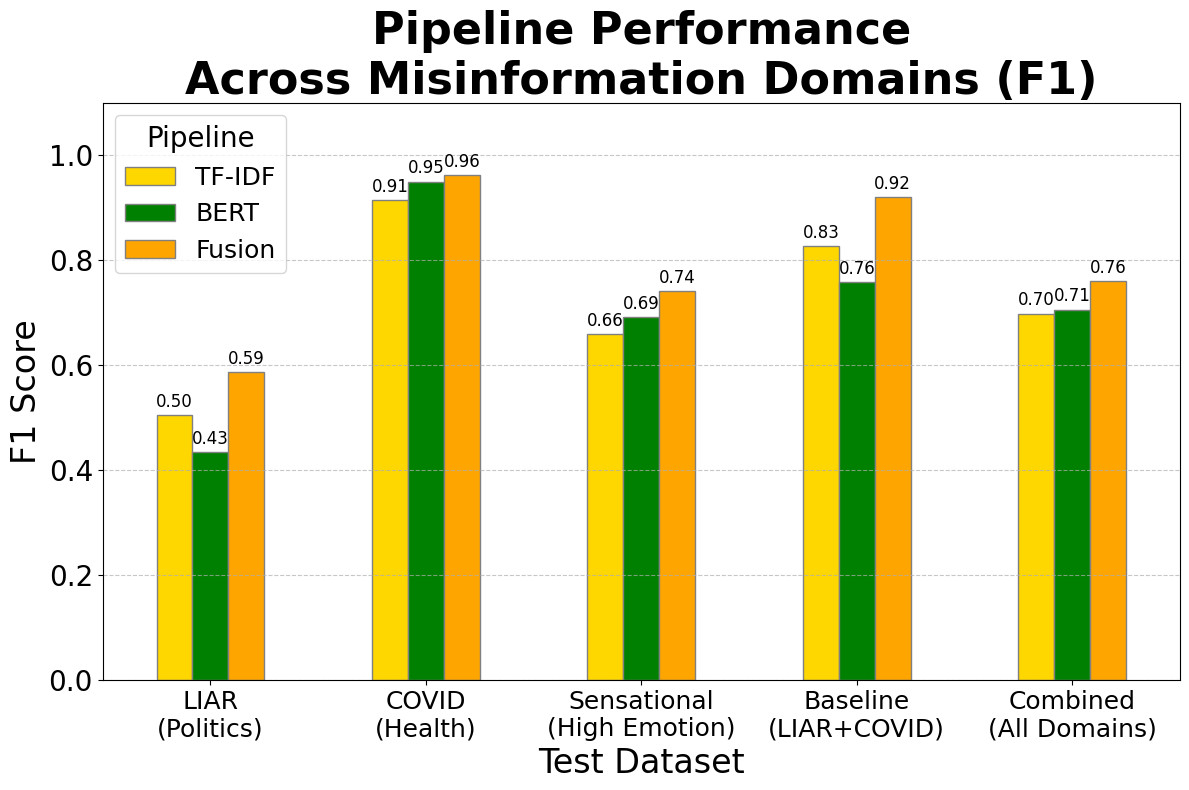

Saved graph: /content/drive/MyDrive/Senior_Project/03_Results/Visuals/pipeline_performance_across_domains_f1.png


In [ ]:
# =========================
# 9. Plot Graph 3
# =========================

pivot_graph3 = graph3_df.pivot(
    index="domain_label",
    columns="pipeline",
    values="f1"
)

# Reorder rows and columns
pivot_graph3 = pivot_graph3.loc[
    [
        "LIAR\n(Politics)",
        "COVID\n(Health)",
        "Sensational\n(High Emotion)",
        "Baseline\n(LIAR+COVID)", # Added baseline to reordering
        "Combined\n(All Domains)"
    ],
    ["TF-IDF", "BERT", "Fusion"]
]

ax = pivot_graph3.plot(
    kind="bar",
    figsize=(12, 8),
    color=["gold", "green", "orange"],
    edgecolor="grey"
)

plt.title("Pipeline Performance\nAcross Misinformation Domains (F1)", fontsize=32, fontweight="bold")
plt.xlabel("Test Dataset", fontsize=24)
plt.ylabel("F1 Score", fontsize=24)
plt.ylim(0, 1.1)

plt.xticks(rotation=0, fontsize=18)
plt.yticks(fontsize=20)
plt.legend(title="Pipeline", fontsize=18, title_fontsize=20)

plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add F1 labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=12, padding=3)

plt.tight_layout()

out_graph = f"{OUT_DIR}/pipeline_performance_across_domains_f1.png"
plt.savefig(out_graph, dpi=300, bbox_inches="tight")
plt.show()

print("Saved graph:", out_graph)

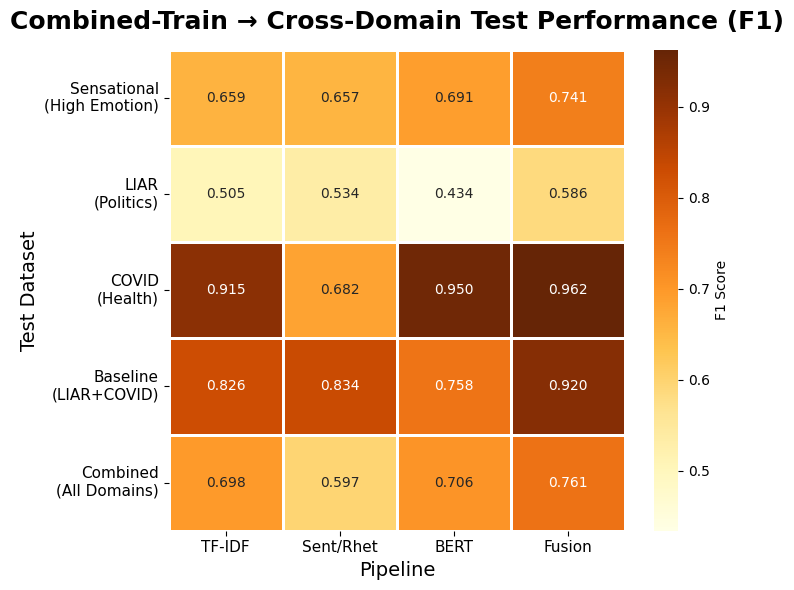

Saved heatmap: /content/drive/MyDrive/Senior_Project/03_Results/Visuals/heatmap_cross_domain_performance.png


,test_dataset,pipeline,f1
0,sensational,TF-IDF,0.658537
1,sensational,Sent/Rhet,0.656891
2,sensational,BERT,0.691057
3,sensational,Fusion,0.741313
4,liar,TF-IDF,0.504535
5,liar,Sent/Rhet,0.533724
6,liar,BERT,0.434066
7,liar,Fusion,0.586042
8,covid,TF-IDF,0.914804
9,covid,Sent/Rhet,0.682322


In [ ]:
# =========================
# Build heatmap from result files
# Combined-trained pipelines → all test datasets
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

test_datasets = ["sensational", "liar", "covid", "baseline", "combined"]

display_names = {
    "sensational": "Sensational\n(High Emotion)",
    "liar": "LIAR\n(Politics)",
    "covid": "COVID\n(Health)",
    "baseline": "Baseline\n(LIAR+COVID)",
    "combined": "Combined\n(All Domains)"
}

rows = []

for test_dataset in test_datasets:

    # TF-IDF
    tfidf_match = tfidf_df[
        (tfidf_df["train_dataset"] == "combined") &
        (tfidf_df["test_dataset"] == test_dataset)
    ]
    if not tfidf_match.empty:
        best = tfidf_match.sort_values("f1", ascending=False).iloc[0]
        rows.append({"test_dataset": test_dataset, "pipeline": "TF-IDF", "f1": best["f1"]})

    # Sentiment/Rhetoric
    sent_match = sent_df[
        (sent_df["train_dataset"] == "combined") &
        (sent_df["test_dataset"] == test_dataset)
    ]
    if not sent_match.empty:
        best = sent_match.sort_values("f1", ascending=False).iloc[0]
        rows.append({"test_dataset": test_dataset, "pipeline": "Sent/Rhet", "f1": best["f1"]})

    # BERT
    bert_match = bert_df[
        (bert_df["bert_model"] == "combined_model") &
        (bert_df["test_dataset"] == test_dataset)
    ]
    if not bert_match.empty:
        best = bert_match.sort_values("f1", ascending=False).iloc[0]
        rows.append({"test_dataset": test_dataset, "pipeline": "BERT", "f1": best["f1"]})

    # Fusion
    fusion_match = fusion_df[
        (fusion_df["experiment"] == "combined_fusion") &
        (fusion_df["test_dataset"] == test_dataset)
    ]
    if not fusion_match.empty:
        best = fusion_match.sort_values("f1", ascending=False).iloc[0]
        rows.append({"test_dataset": test_dataset, "pipeline": "Fusion", "f1": best["f1"]})

graph3_df = pd.DataFrame(rows)

heatmap_df = graph3_df.pivot(
    index="test_dataset",
    columns="pipeline",
    values="f1"
)

heatmap_df = heatmap_df.reindex(test_datasets)
heatmap_df.index = [display_names[x] for x in heatmap_df.index]
heatmap_df = heatmap_df[["TF-IDF", "Sent/Rhet", "BERT", "Fusion"]]

plt.figure(figsize=(7.5, 6))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="YlOrBr",
    linewidths=1,
    cbar_kws={"label": "F1 Score"}
)

plt.title("Combined-Train → Cross-Domain Test Performance (F1)", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Pipeline", fontsize=14)
plt.ylabel("Test Dataset", fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()

out_graph = f"{OUT_DIR}/heatmap_cross_domain_performance.png"
plt.savefig(out_graph, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved heatmap:", out_graph)
display(graph3_df)

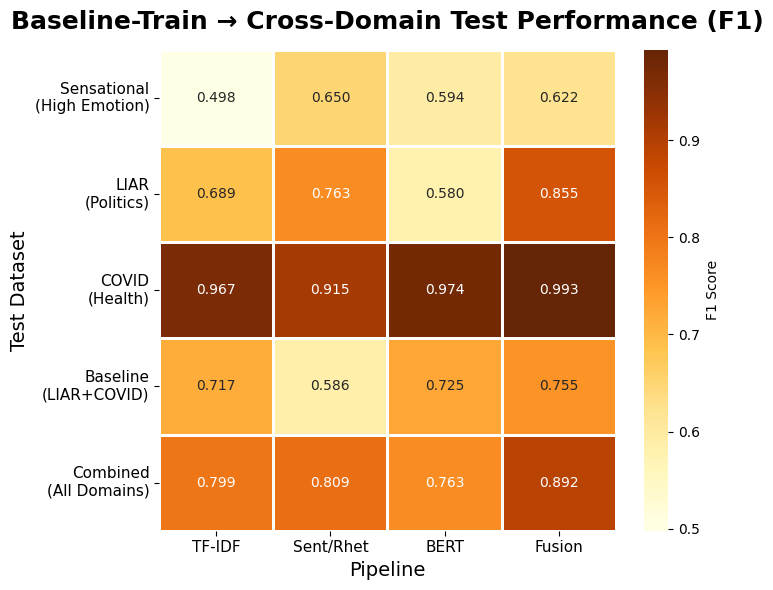

Saved heatmap: /content/drive/MyDrive/Senior_Project/03_Results/Visuals/heatmap_cross_domain_performance.png


,test_dataset,pipeline,f1
0,sensational,TF-IDF,0.498113
1,sensational,Sent/Rhet,0.649573
2,sensational,BERT,0.594427
3,sensational,Fusion,0.622093
4,liar,TF-IDF,0.689094
5,liar,Sent/Rhet,0.763045
6,liar,BERT,0.580124
7,liar,Fusion,0.854962
8,covid,TF-IDF,0.967046
9,covid,Sent/Rhet,0.915296


In [ ]:
# =========================
# Build heatmap from result files
# Combined-trained pipelines → all test datasets
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

test_datasets = ["sensational", "liar", "covid", "baseline", "combined"]

display_names = {
    "sensational": "Sensational\n(High Emotion)",
    "liar": "LIAR\n(Politics)",
    "covid": "COVID\n(Health)",
    "baseline": "Baseline\n(LIAR+COVID)",
    "combined": "Combined\n(All Domains)"
}

rows = []

for test_dataset in test_datasets:

    # TF-IDF
    tfidf_match = tfidf_df[
        (tfidf_df["train_dataset"] == "baseline") &
        (tfidf_df["test_dataset"] == test_dataset)
    ]
    if not tfidf_match.empty:
        best = tfidf_match.sort_values("f1", ascending=False).iloc[0]
        rows.append({"test_dataset": test_dataset, "pipeline": "TF-IDF", "f1": best["f1"]})

    # Sentiment/Rhetoric
    sent_match = sent_df[
        (sent_df["train_dataset"] == "baseline") &
        (sent_df["test_dataset"] == test_dataset)
    ]
    if not sent_match.empty:
        best = sent_match.sort_values("f1", ascending=False).iloc[0]
        rows.append({"test_dataset": test_dataset, "pipeline": "Sent/Rhet", "f1": best["f1"]})

    # BERT
    bert_match = bert_df[
        (bert_df["bert_model"] == "baseline_model") &
        (bert_df["test_dataset"] == test_dataset)
    ]
    if not bert_match.empty:
        best = bert_match.sort_values("f1", ascending=False).iloc[0]
        rows.append({"test_dataset": test_dataset, "pipeline": "BERT", "f1": best["f1"]})

    # Fusion
    fusion_match = fusion_df[
        (fusion_df["experiment"] == "baseline_fusion") &
        (fusion_df["test_dataset"] == test_dataset)
    ]
    if not fusion_match.empty:
        best = fusion_match.sort_values("f1", ascending=False).iloc[0]
        rows.append({"test_dataset": test_dataset, "pipeline": "Fusion", "f1": best["f1"]})

graph3_df = pd.DataFrame(rows)

heatmap_df = graph3_df.pivot(
    index="test_dataset",
    columns="pipeline",
    values="f1"
)

heatmap_df = heatmap_df.reindex(test_datasets)
heatmap_df.index = [display_names[x] for x in heatmap_df.index]
heatmap_df = heatmap_df[["TF-IDF", "Sent/Rhet", "BERT", "Fusion"]]

plt.figure(figsize=(7.5, 6))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="YlOrBr",
    linewidths=1,
    cbar_kws={"label": "F1 Score"}
)

plt.title("Baseline-Train → Cross-Domain Test Performance (F1)", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Pipeline", fontsize=14)
plt.ylabel("Test Dataset", fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()

out_graph = f"{OUT_DIR}/heatmap_cross_domain_performance.png"
plt.savefig(out_graph, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved heatmap:", out_graph)
display(graph3_df)



---

graph 2 redos


In [ ]:
# =========================
# DATA FOR GRAPH 2
# Fusion Model Generalization Across Domains
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Replace with your REAL values if needed
domains = [
    "LIAR\n(Politics)",
    "COVID\n(Health)",
    "Baseline\n(LIAR+COVID)",
    "Sensational\n(Emotional)",
    "Combined\n(All Domains)"
]

f1_scores = [0.520, 0.954, 0.921, 0.728, 0.730]

plot_df = pd.DataFrame({
    "domain": domains,
    "f1": f1_scores
})

In [ ]:
# =========================
# Data: Fusion generalization
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

graph2_df = fusion_df[
    (fusion_df["experiment"] == "combined_fusion") &
    (fusion_df["fusion_model"] == "Fusion_RF")
].copy()

domain_order = ["liar", "covid", "baseline", "sensational", "combined"]

label_map = {
    "liar": "LIAR\n(Politics)",
    "covid": "COVID\n(Health)",
    "baseline": "Baseline\n(LIAR+COVID)",
    "sensational": "Sensational\n(Emotional)",
    "combined": "Combined\n(All Domains)"
}

graph2_df["test_dataset"] = pd.Categorical(
    graph2_df["test_dataset"],
    categories=domain_order,
    ordered=True
)

graph2_df = graph2_df.sort_values("test_dataset")
graph2_df["domain_label"] = graph2_df["test_dataset"].map(label_map)

graph2_df[["domain_label", "f1"]]

,domain_label,f1
17,LIAR\n(Politics),0.553672
15,COVID\n(Health),0.962379
11,Baseline\n(LIAR+COVID),0.919780
19,Sensational\n(Emotional),0.727273
13,Combined\n(All Domains),0.749180


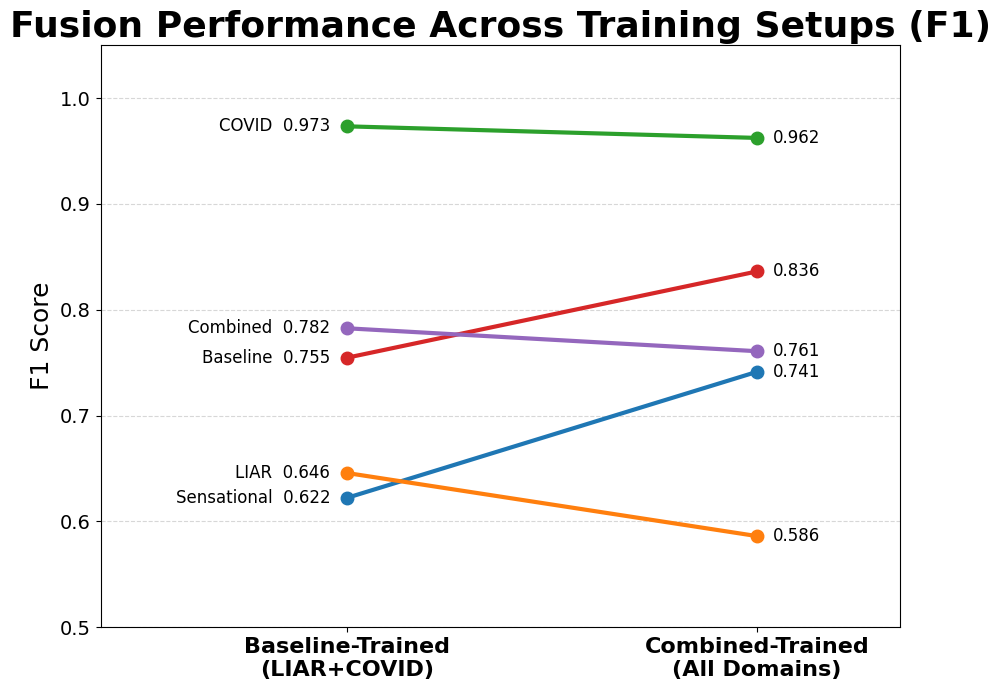

Saved: /content/drive/MyDrive/Senior_Project/03_Results/Visuals/fusion_slope_chart.png


In [98]:
# =========================
# Slope Chart
# Baseline Fusion vs Combined Fusion
# =========================

slope_df = fusion_df[
    (fusion_df["fusion_model"] == "Fusion_LogReg") &
    (fusion_df["experiment"].isin(["baseline_fusion", "combined_fusion"]))
].copy()

slope_df["test_dataset"] = pd.Categorical(
    slope_df["test_dataset"],
    categories=domain_order,
    ordered=True
)

slope_pivot = slope_df.pivot(
    index="test_dataset",
    columns="experiment",
    values="f1"
).reset_index()

slope_pivot = slope_pivot.sort_values("test_dataset")
slope_pivot["domain_label"] = slope_pivot["test_dataset"].map(label_map)
slope_pivot["domain_label"] = slope_pivot["domain_label"].str.replace(r'\s*\([^)]*\)', '', regex=True)

fig, ax = plt.subplots(figsize=(9, 7))

x_positions = [0, 1]

for _, row in slope_pivot.iterrows():
    y1 = row["baseline_fusion"]
    y2 = row["combined_fusion"]

    ax.plot(
        x_positions,
        [y1, y2],
        marker="o",
        linewidth=3,
        markersize=9
    )

    ax.text(-0.04, y1, f"{row['domain_label']}  {y1:.3f}",
            ha="right", va="center", fontsize=12)

    ax.text(1.04, y2, f"{y2:.3f}",
            ha="left", va="center", fontsize=12)

ax.set_xlim(-0.6, 1.35) # Increased left limit for more space
ax.set_ylim(0.5, 1.05)

ax.set_xticks(x_positions)
ax.set_xticklabels(
    ["Baseline-Trained\n(LIAR+COVID)", "Combined-Trained\n(All Domains)"],
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("F1 Score", fontsize=18)
ax.set_title(
    "Fusion Performance Across Training Setups (F1)",
    fontsize=26,
    fontweight="bold"
)

ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.yticks(fontsize=14)
plt.tight_layout()

out_graph = f"{OUT_DIR}/fusion_slope_chart.png"
plt.savefig(out_graph, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_graph)


### Pipeline Performance on Sensational Domain

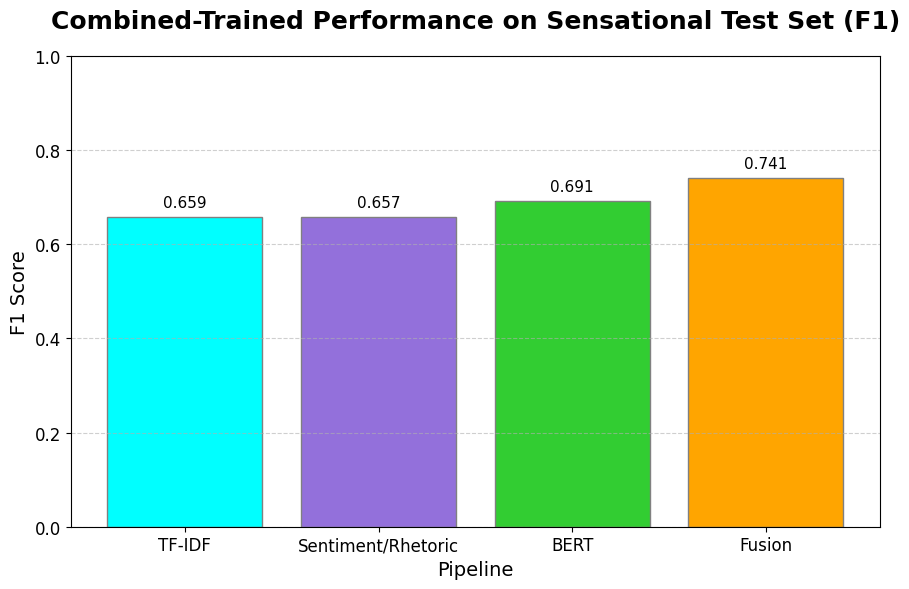

Saved graph: /content/drive/MyDrive/Senior_Project/03_Results/Visuals/combined_to_sensational_pipeline_comparison_f1.png


In [ ]:
# =========================
# Graph: Combined → Sensational pipeline comparison
# =========================

plot_df = combined_to_sens_df.copy()

plot_df["pipeline"] = pd.Categorical(
    plot_df["pipeline"],
    categories=["TF-IDF", "Sentiment/Rhetoric", "BERT", "Fusion"],
    ordered=True
)

plot_df = plot_df.sort_values("pipeline")

plt.figure(figsize=(9, 6))

colors = ["cyan", "mediumpurple", "limegreen", "orange"]

bars = plt.bar(
    plot_df["pipeline"],
    plot_df["f1"],
    color=colors,
    edgecolor="grey"
)

plt.title(
    "Combined-Trained Performance on Sensational Test Set (F1)",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Pipeline", fontsize=14)
plt.ylabel("F1 Score", fontsize=14)
plt.ylim(0, 1)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

out_graph = f"{OUT_DIR}/combined_to_sensational_pipeline_comparison_f1.png"
plt.savefig(out_graph, dpi=300, bbox_inches="tight")
plt.show()

print("Saved graph:", out_graph)



---



In [ ]:
# =========================
# Final Performance Summary
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import os

# =========================
# Build summary rows
# =========================

summary_rows = []

# -------------------------
# Best Combined Test Result
# -------------------------

combined_candidates = []

# TF-IDF
tfidf_combined = tfidf_df[
    (tfidf_df["train_dataset"] == "combined") &
    (tfidf_df["test_dataset"] == "combined")
]

best_tfidf = tfidf_combined.sort_values("f1", ascending=False).iloc[0]

combined_candidates.append({
    "pipeline": "TF-IDF",
    "f1": best_tfidf["f1"]
})

# Sentiment/Rhetoric
sent_combined = sent_df[
    (sent_df["train_dataset"] == "combined") &
    (sent_df["test_dataset"] == "combined")
]

best_sent = sent_combined.sort_values("f1", ascending=False).iloc[0]

combined_candidates.append({
    "pipeline": "Sentiment/Rhetoric",
    "f1": best_sent["f1"]
})

# BERT
bert_combined = bert_df[
    (bert_df["bert_model"] == "combined_model") &
    (bert_df["test_dataset"] == "combined")
]

best_bert = bert_combined.sort_values("f1", ascending=False).iloc[0]

combined_candidates.append({
    "pipeline": "BERT",
    "f1": best_bert["f1"]
})

# Fusion
fusion_combined = fusion_df[
    (fusion_df["experiment"] == "combined_fusion") &
    (fusion_df["test_dataset"] == "combined")
]

best_fusion_combined = fusion_combined.sort_values("f1", ascending=False).iloc[0]

combined_candidates.append({
    "pipeline": "Fusion",
    "f1": best_fusion_combined["f1"]
})

combined_candidates_df = pd.DataFrame(combined_candidates)

best_combined = combined_candidates_df.sort_values(
    "f1",
    ascending=False
).iloc[0]

summary_rows.append({
    "finding": "Best Overall\nCombined Test",
    "pipeline": best_combined["pipeline"],
    "f1": best_combined["f1"]
})

# -------------------------
# Best Emotional Domain
# -------------------------

sens_candidates = []

# TF-IDF
tfidf_sens = tfidf_df[
    (tfidf_df["train_dataset"] == "combined") &
    (tfidf_df["test_dataset"] == "sensational")
]

sens_candidates.append({
    "pipeline": "TF-IDF",
    "f1": tfidf_sens.sort_values("f1", ascending=False).iloc[0]["f1"]
})

# Sentiment/Rhetoric
sent_sens = sent_df[
    (sent_df["train_dataset"] == "combined") &
    (sent_df["test_dataset"] == "sensational")
]

sens_candidates.append({
    "pipeline": "Sentiment/Rhetoric",
    "f1": sent_sens.sort_values("f1", ascending=False).iloc[0]["f1"]
})

# BERT
bert_sens = bert_df[
    (bert_df["bert_model"] == "combined_model") &
    (bert_df["test_dataset"] == "sensational")
]

sens_candidates.append({
    "pipeline": "BERT",
    "f1": bert_sens.sort_values("f1", ascending=False).iloc[0]["f1"]
})

# Fusion
fusion_sens = fusion_df[
    (fusion_df["experiment"] == "combined_fusion") &
    (fusion_df["test_dataset"] == "sensational")
]

sens_candidates.append({
    "pipeline": "Fusion",
    "f1": fusion_sens.sort_values("f1", ascending=False).iloc[0]["f1"]
})

sens_candidates_df = pd.DataFrame(sens_candidates)

best_sens = sens_candidates_df.sort_values(
    "f1",
    ascending=False
).iloc[0]

summary_rows.append({
    "finding": "Best Emotional\nDomain Test",
    "pipeline": best_sens["pipeline"],
    "f1": best_sens["f1"]
})

# -------------------------
# Best Fusion Result Overall
# -------------------------

best_fusion_overall = fusion_df.sort_values(
    "f1",
    ascending=False
).iloc[0]

summary_rows.append({
    "finding": "Best Fusion\nResult",
    "pipeline": best_fusion_overall["fusion_model"],
    "f1": best_fusion_overall["f1"]
})

# =========================
# Create summary dataframe
# =========================

summary_df = pd.DataFrame(summary_rows)

summary_df

,finding,pipeline,f1
0,Best Overall\nCombined Test,Fusion,0.760824
1,Best Emotional\nDomain Test,Fusion,0.741313
2,Best Fusion\nResult,Fusion_RF,0.992806
